<a href="https://colab.research.google.com/github/CyberBitCode/my-project/blob/main/Breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**Breast Cancer**
#### **Problem Statement**
Breast cancer is one of the most common and life-threatening diseases. Early and accurate detection is crucial for effective treatment.
The goal of this project is to develop a machine learning model that can accurately classify tumors as benign or malignant based on various cell nucleus features extracted from medical images.
This classification problem is a supervised binary classification task, where the model learns patterns from labeled data to make predictions on unseen data.

####**Objectives**
* To build a machine learning model to classify tumors as benign or malignant
* To compare the performance of Random Forest and XGBoost algorithms
* To evaluate models using holdout validation and k-fold cross-validation
* To analyze feature importance and identify key predictors
* To understand the impact of feature relationships and correlations on model performance

###**Dataset Description**
The dataset contains features computed from digitized images of breast mass cell nuclei
Each sample represents measurements of a tumor
Target variable:
* 0 → Benign
* 1 → Malignant

The dataset consists of three types of features:
1. **Mean Features**
* radius_mean
* texture_mean
* perimeter_mean
* area_mean
* smoothness_mean
* compactness_mean
* concavity_mean
* concave points_mean
* symmetry_mean
* fractal_dimension_mean

2. **Standard Error Features (_se)**
* radius_se
* texture_se
* perimeter_se
* area_se
* smoothness_se
* compactness_se
* concavity_se
* concave points_se
* symmetry_se
* fractal_dimension_se
3. **Worst Features (_worst)**
* radius_worst
* texture_worst
* perimeter_worst
* area_worst
* smoothness_worst
* compactness_worst
* concavity_worst
* concave points_worst
* symmetry_worst
* fractal_dimension_worst

### **Target Variable**

* diagnosis
* 0 → Benign
* 1 → Malignant

In [ ]:
# To filter the warnings
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split


# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, roc_auc_score

In [ ]:
# Reading the file
data = pd.read_csv('/content/data.csv')

In [ ]:
# Checking the first few rows:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


### Understand the shape of the dataset

In [ ]:
data.shape

(569, 33)

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

* There are no null values
* id and Unnamed: 32 are not required columns. So we will get rid of those.

There are two outcomes -
* Benign Tumor (which spreads locally)  
 * Malignant Tumor (which can spread throughout the whole body via blood)

In [ ]:
# Dropping some of the unwanted variables:
data.drop('id',axis=1,inplace=True)
data.drop('Unnamed: 32',axis=1,inplace=True)

In [ ]:
# Binarizing the target variable:
data['diagnosis'] = data['diagnosis'].map({'M':1,'B':0})

The data is highly variable and any feature with low variance will be neglected. We will scale the data to allow more predictive power.
Here we are standardizing the dataset - meaning shifting the distribution to have mean of zero and standard deviation of unit variance

### EDA

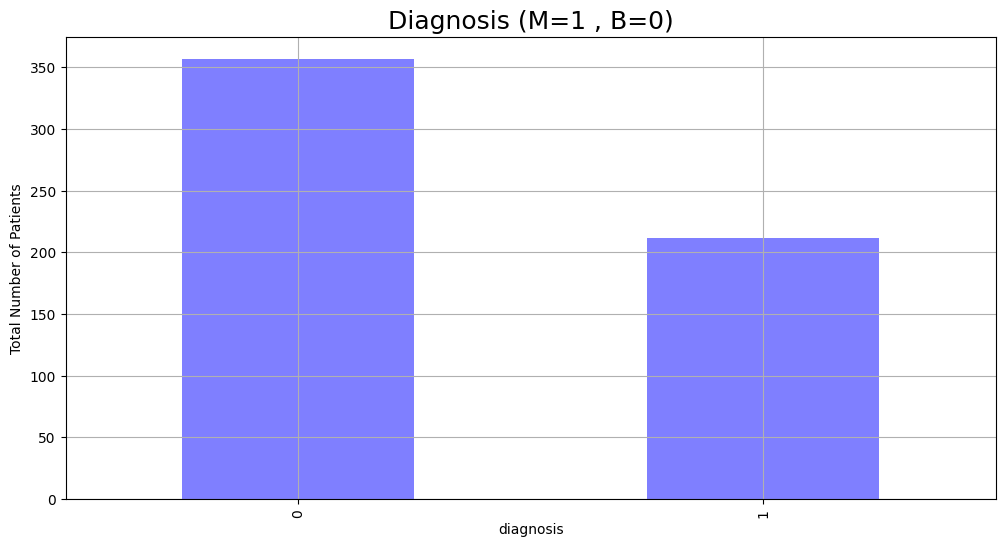

In [ ]:
#Looking at the number of patients with Malignant and Benign Tumors:
data.diagnosis.value_counts().plot(kind='bar', alpha = 0.5, facecolor = 'b', figsize=(12,6))
plt.title("Diagnosis (M=1 , B=0)", fontsize = '18')
plt.ylabel("Total Number of Patients")
plt.grid(visible=True)

* ~ 65% of the patients had Benign tumor while the rest of them had Malignant.

#### Considering only mean features of nucleus

In [ ]:
data.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
data_mean = data[['diagnosis','radius_mean','texture_mean','perimeter_mean',
                  'area_mean','smoothness_mean', 'compactness_mean',
                  'concavity_mean','concave points_mean', 'symmetry_mean',
                  'fractal_dimension_mean']]

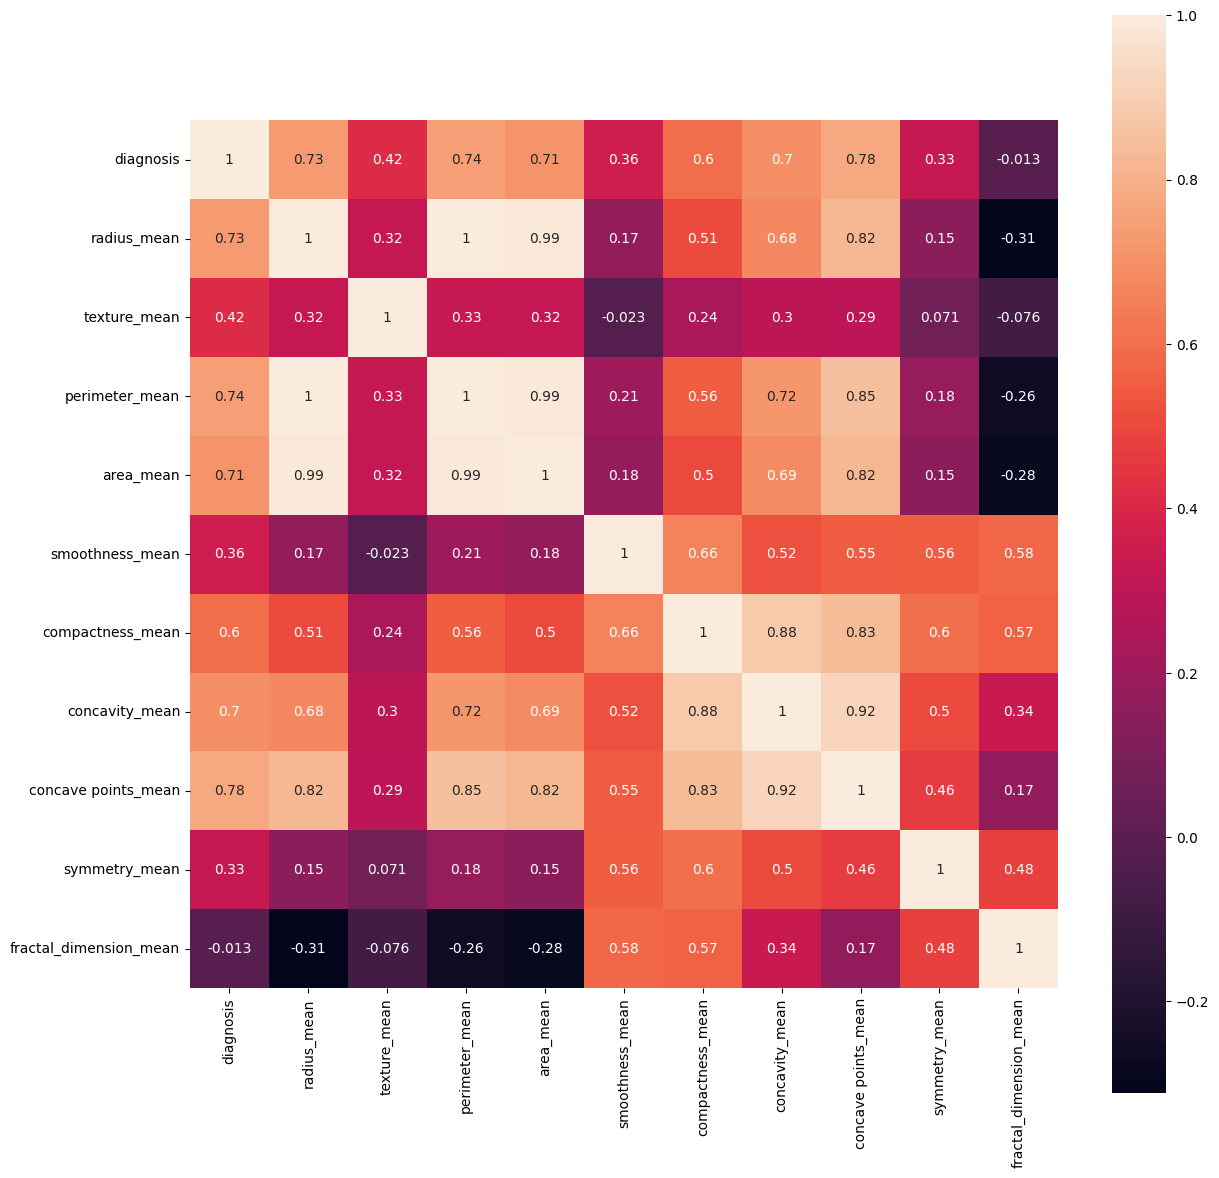

In [ ]:
plt.figure(figsize=(14,14))
foo = sns.heatmap(data_mean.corr(), vmax=1, square=True, annot=True)


* Radius_mean, perimeter_mean, area_mean, compactness_mean, concavity_mean, concave points_mean show high coorelation with the diagnosis.

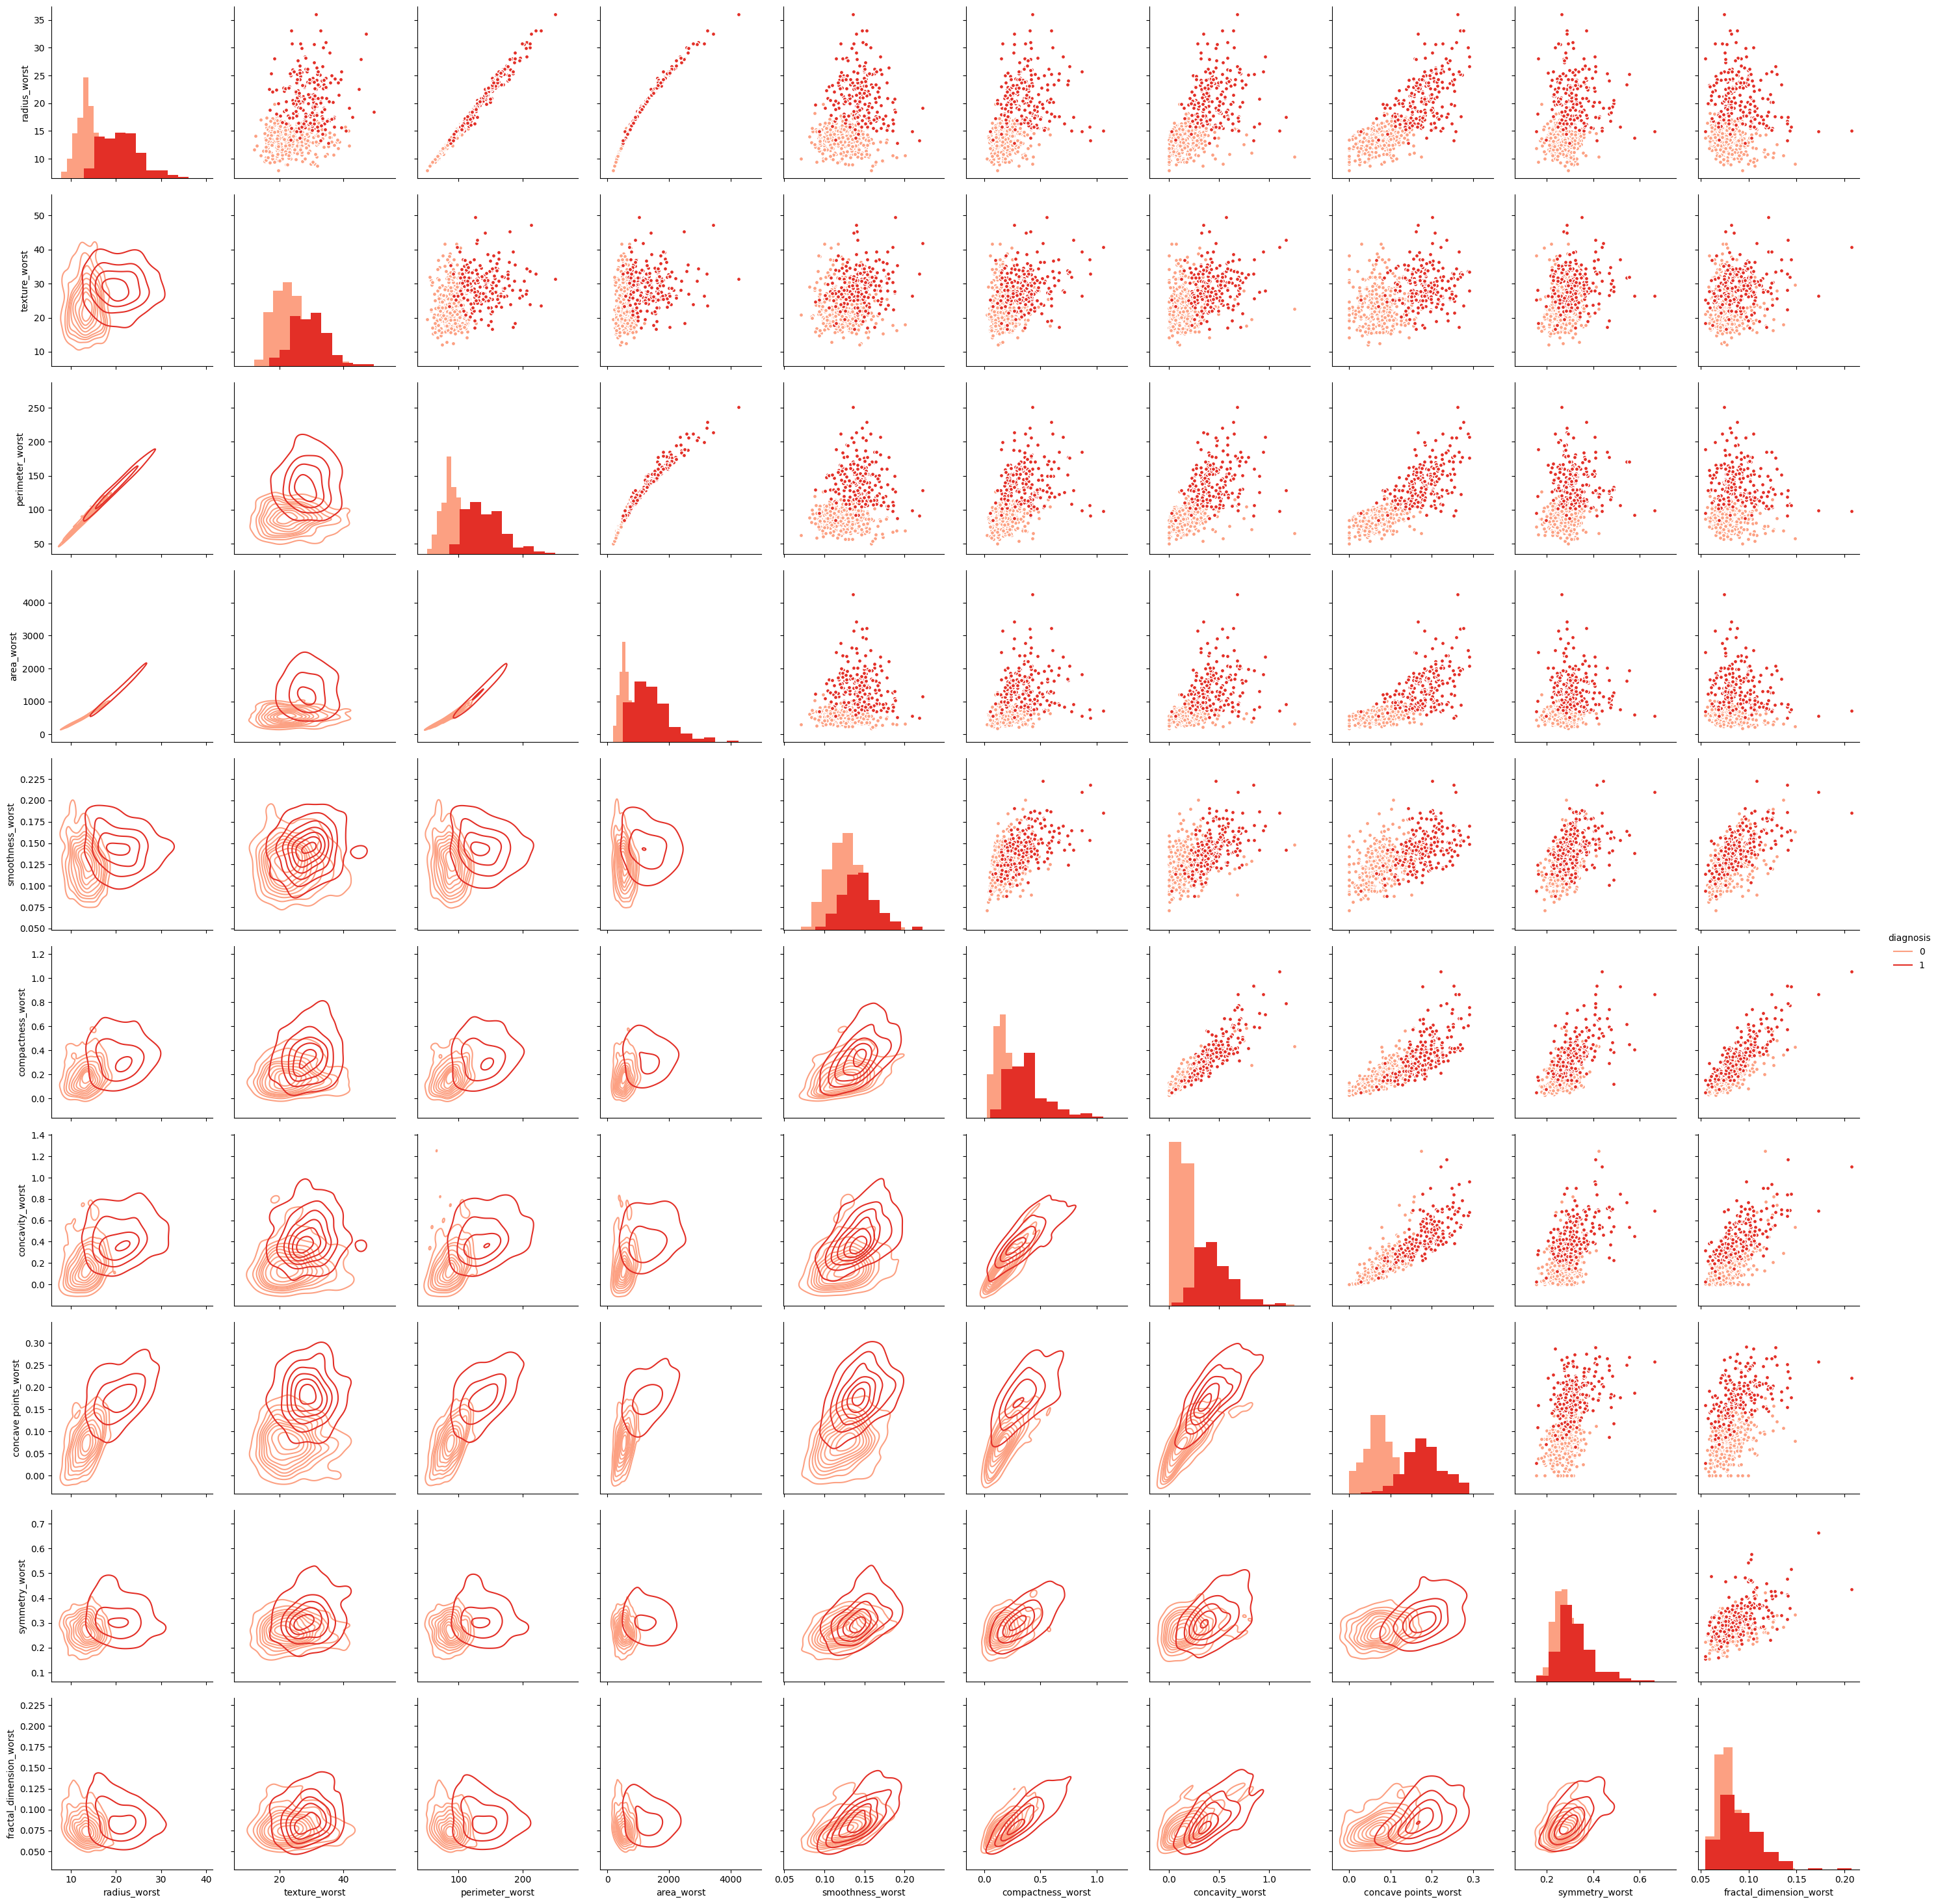

In [ ]:
from pandas.plotting import scatter_matrix

# Create a list of column names for the 'worst' features to be plotted
worst_features = data.columns[21:32].tolist() # Columns 21 to 31 are 'worst' features

p = sns.PairGrid(data, vars=worst_features, hue = 'diagnosis', palette = 'Reds')
p.map_upper(plt.scatter, s = 20, edgecolor = 'w')
p.map_diag(plt.hist)
p.map_lower(sns.kdeplot)
p.add_legend()

p.fig.set_size_inches(30,30) # Correct way to set the figure size
plt.show()

In this case, especially for features like radius_worst, perimeter_worst, and area_worst. These visual separations often indicate strong predictive power.It helps us see how each 'worst' feature is distributed for both benign (B) and malignant (M) diagnoses, as well as the scatter plots of each pair of features, colored by diagnosis. This allows for a visual inspection of potential separation between the two diagnosis groups based on these features.

### Let's look at the distribution of target variable

In [ ]:
data["diagnosis"].value_counts()

,count
diagnosis,
0,357
1,212


In [ ]:
data["diagnosis"].value_counts(1)

,proportion
diagnosis,
0,0.627417
1,0.372583


* The number of observations where the person is Malignant are 357 which is 62% of the total data available.

### Feature Importance for Random Forest Model

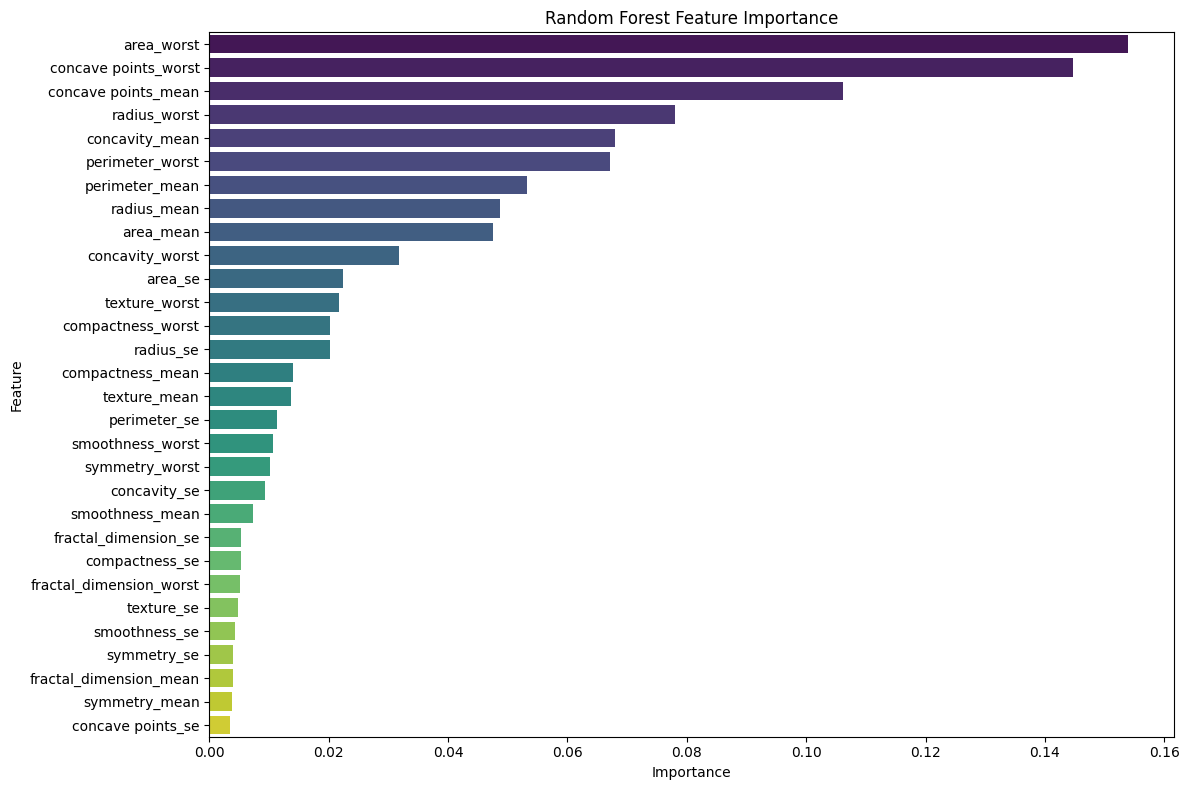

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
rf_feature_importances = pd.DataFrame({'feature': X.columns, 'importance': rf_model.feature_importances_})

# Sort features by importance
rf_feature_importances = rf_feature_importances.sort_values('importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=rf_feature_importances, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

* Top features include area (worst), concave points, radius, and perimeter.
* Focus is slightly more on tumor size features (area, radius).
* Feature importance is more evenly distributed compared to XGBoost.
* Many features still contribute, but with smaller impact

### Splitting data into train and test

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42) # Using random_state for reproducibility

# Train the model on the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model and generate classification report
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Model Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report (Random Forest):\n", classification_report(y_test, y_pred_rf))

Random Forest Model Accuracy: 0.9649

Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Random Forest Model Accuracy: 0.9649

Classification Report (Random Forest):

* Precision:

     * For class 0 (Benign), the precision is 0.96, meaning 96% of the instances predicted as Benign were actually Benign.
    * For class 1 (Malignant), the precision is 0.98, meaning 98% of the instances predicted as Malignant were actually Malignant.
* Recall:

   * For class 0, the recall is 0.99, indicating that 99% of all actual Benign cases were correctly identified.
   * For class 1, the recall is 0.93, meaning 93% of all actual Malignant cases were correctly identified.
* F1-score: This is the harmonic mean of precision and recall. It's 0.97 for Benign and 0.95 for Malignant, showing a good balance between precision and recall for both classes.
* Support: There were 71 actual Benign cases and 43 actual Malignant cases in the test set.

Overall, the model demonstrates strong performance in classifying breast cancer diagnoses, with high accuracy and balanced precision and recall for both benign and malignant cases.

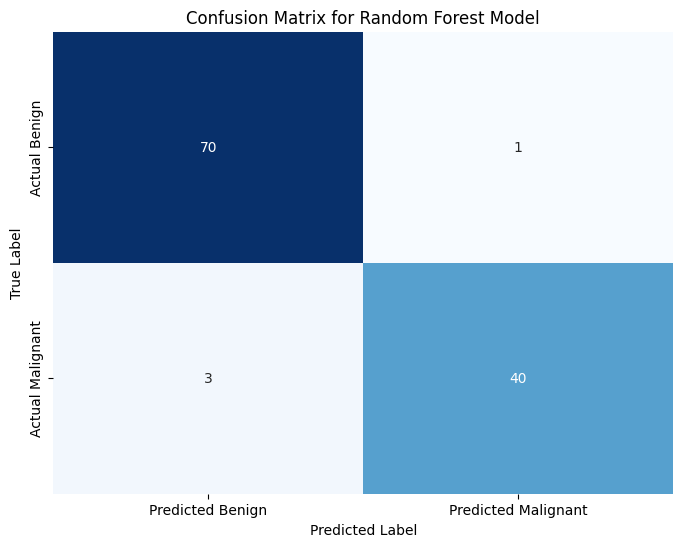

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix for Random Forest Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix for the Random Forest model has been generated. From this matrix, we can see:

* True Negatives:  70 cases were correctly predicted as Benign (Class 0).
* False Positives: 1 case was incorrectly predicted as Malignant (Class 1) when it was actually Benign. These are Type I errors.
* False Negatives: 3 cases were incorrectly predicted as Benign (Class 0) when they were actually Malignant. These are Type II errors, which are often more critical in medical diagnoses.
* True Positives: 40 cases were correctly predicted as Malignant (Class 1).

This matrix provides a detailed view of how well the model distinguishes between benign and malignant tumors, highlighting its strengths and areas for potential improvement.

### Feature Importance for XGBoost Model

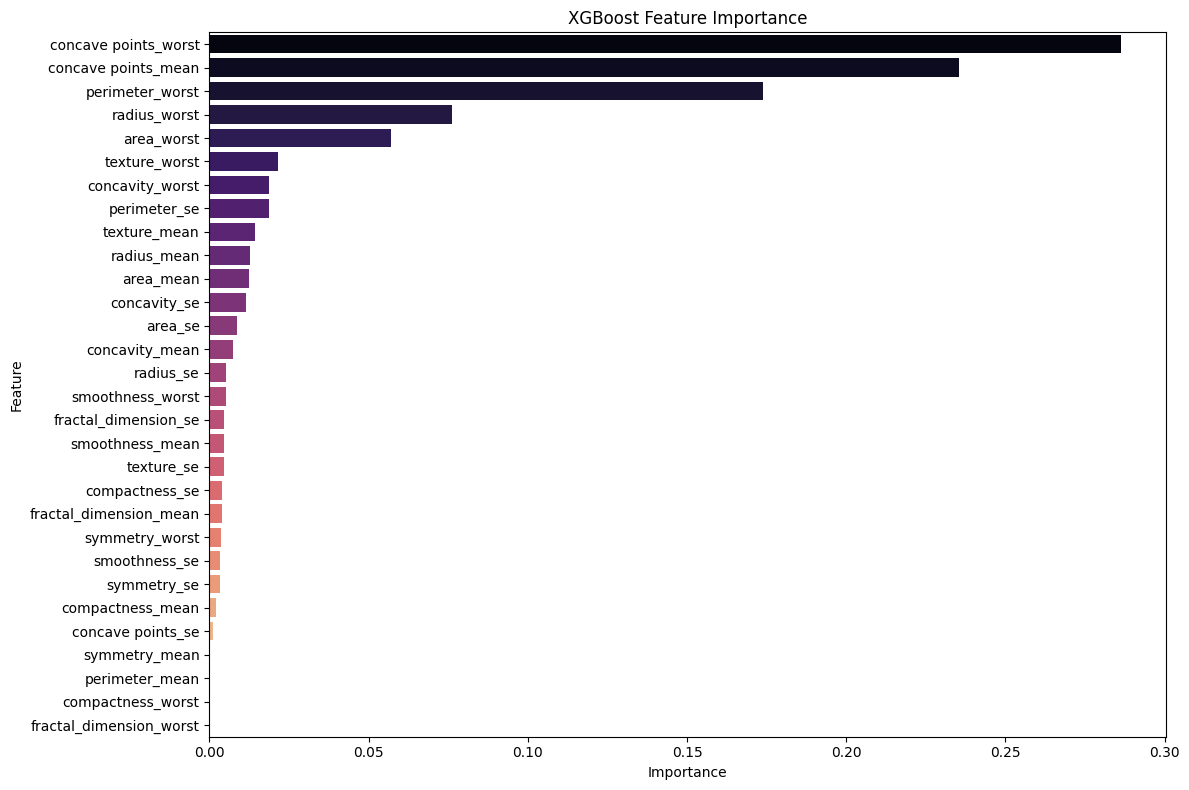

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the XGBoost model
xgb_feature_importances = pd.DataFrame({'feature': X.columns, 'importance': xgb_model.feature_importances_})

# Sort features by importance
xgb_feature_importances = xgb_feature_importances.sort_values('importance', ascending=False)

# Plotting feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=xgb_feature_importances, palette='magma')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

* Top features include concave points (worst & mean), perimeter, radius, and area.
* Strong emphasis on tumor shape irregularity (concave points).
* Size-related features also play a significant role.
* Importance is more concentrated on a few top features.
* Lower-ranked features contribute very little.

### XG Boost Model

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss') # Using random_state for reproducibility

# Train the model on the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model and generate classification report
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Model Accuracy: {accuracy_xgb:.4f}")
print("\nClassification Report (XGBoost):\n", classification_report(y_test, y_pred_xgb))

XGBoost Model Accuracy: 0.9561

Classification Report (XGBoost):
               precision    recall  f1-score   support

           0       0.96      0.97      0.97        71
           1       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



XGBoost Model Accuracy: 0.9561

Classification Report (XGBoost):

* Precision:
     * For class 0 (Benign), the precision is 0.96, meaning 96% of the instances predicted as Benign were actually Benign.
     * For class 1 (Malignant), the precision is 0.95, meaning 95% of the instances predicted as Malignant were actually Malignant.
* Recall:
   * For class 0, the recall is 0.97, indicating that 97% of all actual Benign cases were correctly identified.
   * For class 1, the recall is 0.93, meaning 93% of all actual Malignant cases were correctly identified.
* F1-score: This is the harmonic mean of precision and recall. It's 0.97 for Benign and 0.94 for Malignant, showing a good balance between precision and recall for both classes.
* Support: There were 71 actual Benign cases and 43 actual Malignant cases in the test set.

Overall, the XGBoost model shows strong performance, slightly outperforming the Random Forest model in terms of recall for class 0.

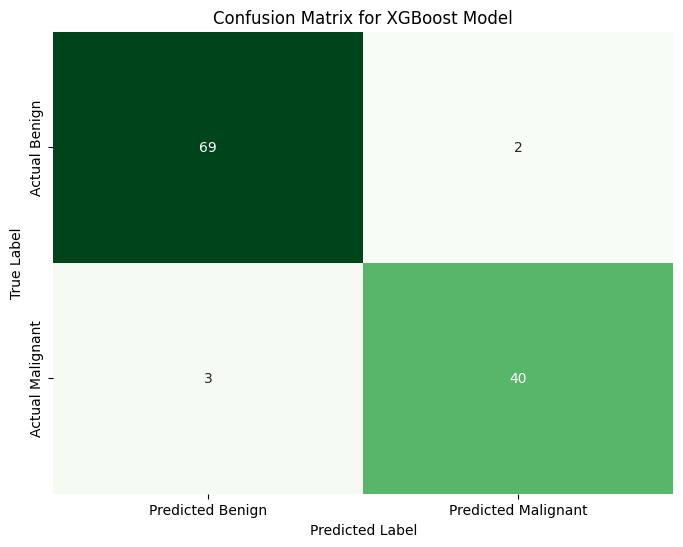

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute the confusion matrix for XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Benign', 'Predicted Malignant'],
            yticklabels=['Actual Benign', 'Actual Malignant'])
plt.title('Confusion Matrix for XGBoost Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix for the XGBoost model, From this matrix, we can see:

* True Negatives: 69 cases were correctly predicted as Benign (Class 0).
* False Positives: 2 cases were incorrectly predicted as Malignant (Class 1) when they were actually Benign. These are Type I errors.
* False Negatives: 3 cases were incorrectly predicted as Benign (Class 0) when they were actually Malignant. These are Type II errors, which are often more critical in medical diagnoses.
* True Positives: 40 cases were correctly predicted as Malignant (Class 1).

This confirms the model's performance in distinguishing between benign and malignant tumors.



### K-Fold Cross-Validation

In [ ]:
# k-Fold Cross-Validation for Random Forest
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='accuracy')

print(f"Random Forest K-Fold Cross-Validation Scores: {cv_scores_rf}")
print(f"Random Forest Mean Accuracy (K-Fold): {cv_scores_rf.mean():.4f}")
print(f"Random Forest Standard Deviation (K-Fold): {cv_scores_rf.std():.4f}\n")

Random Forest K-Fold Cross-Validation Scores: [0.96491228 0.96491228 0.98245614 0.96491228 0.96491228 0.94736842
 0.96491228 0.94736842 0.96491228 0.96428571]
Random Forest Mean Accuracy (K-Fold): 0.9631
Random Forest Standard Deviation (K-Fold): 0.0094



In [ ]:
# k-Fold Cross-Validation for XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='accuracy')

print(f"XGBoost K-Fold Cross-Validation Scores: {cv_scores_xgb}")
print(f"XGBoost Mean Accuracy (K-Fold): {cv_scores_xgb.mean():.4f}")
print(f"XGBoost Standard Deviation (K-Fold): {cv_scores_xgb.std():.4f}")

XGBoost K-Fold Cross-Validation Scores: [0.96491228 0.96491228 0.96491228 1.         0.98245614 0.92982456
 0.98245614 0.98245614 0.96491228 0.92857143]
XGBoost Mean Accuracy (K-Fold): 0.9665
XGBoost Standard Deviation (K-Fold): 0.0216


The k-Fold cross-validation results and compare the models:

* Random Forest Model (K-Fold Cross-Validation):

   * Mean Accuracy: 0.9631
    * Standard Deviation: 0.0094

* XGBoost Model (K-Fold Cross-Validation):

    * Mean Accuracy: 0.9665
    * Standard Deviation: 0.0216


### Model Comparison:

* Performance: The XGBoost model shows a slightly higher mean accuracy (0.9665) compared to the Random Forest model (0.9631) across the 10 folds. This suggests that, on average, XGBoost performs marginally better on unseen data for this dataset.

* Stability: The Random Forest model has a slightly lower standard deviation (0.0094) than XGBoost (0.0216). A lower standard deviation indicates that the model's performance is more consistent across different folds. While both models are quite stable, Random Forest shows slightly less variance in its performance.

### Why is K-Fold Cross-Validation Important?

* Robust Performance Estimate: It provides a more reliable estimate of how well a model will generalize to independent datasets compared to a single train-test split. By training and testing on multiple subsets of the data, it reduces the impact of a particular split's randomness.
* Reduces Overfitting: It helps in detecting and mitigating overfitting. If a model performs very well on the training set but poorly on the test sets in cross-validation, it's likely overfitting.
* Better Use of Data: In scenarios with limited data, cross-validation ensures that every data point gets to be in a test set exactly once and in a training set k-1 times. This makes more efficient use of the available data compared to a single holdout set.
* Model Selection and Hyperparameter Tuning: It's essential for comparing different models or tuning hyperparameters. You can choose the model or hyperparameters that yield the best average performance across all folds.

In summary, while both models perform very well, XGBoost shows a slight edge in average accuracy, and Random Forest demonstrates slightly more consistent performance.

### Stratified K-Fold Cross-Validation

Stratified K-Fold cross-validation is a variation of k-fold cross-validation that returns stratified folds. The folds are made by preserving the percentage of samples for each class. This is particularly useful for classification problems with imbalanced class distributions.

In [ ]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print("\n--- Stratified K-Fold Cross-Validation ---\n")

# Stratified k-Fold Cross-Validation for Random Forest
cv_scores_rf_stratified = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy')

print(f"Random Forest Stratified K-Fold Cross-Validation Scores: {cv_scores_rf_stratified}")
print(f"Random Forest Mean Accuracy (Stratified K-Fold): {cv_scores_rf_stratified.mean():.4f}")
print(f"Random Forest Standard Deviation (Stratified K-Fold): {cv_scores_rf_stratified.std():.4f}\n")



--- Stratified K-Fold Cross-Validation ---

Random Forest Stratified K-Fold Cross-Validation Scores: [0.94736842 0.98245614 0.96491228 0.9122807  0.94736842 0.96491228
 0.96491228 0.94736842 0.92982456 1.        ]
Random Forest Mean Accuracy (Stratified K-Fold): 0.9561
Random Forest Standard Deviation (Stratified K-Fold): 0.0239



In [ ]:
# Stratified k-Fold Cross-Validation for XGBoost
cv_scores_xgb_stratified = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')

print(f"XGBoost Stratified K-Fold Cross-Validation Scores: {cv_scores_xgb_stratified}")
print(f"XGBoost Mean Accuracy (Stratified K-Fold): {cv_scores_xgb_stratified.mean():.4f}")
print(f"XGBoost Standard Deviation (Stratified K-Fold): {cv_scores_xgb_stratified.std():.4f}")

XGBoost Stratified K-Fold Cross-Validation Scores: [0.94736842 0.94736842 0.98245614 0.9122807  0.96491228 0.98245614
 1.         0.92982456 0.92982456 0.98214286]
XGBoost Mean Accuracy (Stratified K-Fold): 0.9579
XGBoost Standard Deviation (Stratified K-Fold): 0.0274


The Stratified K-Fold cross-validation results computed for both models:

* Random Forest Model (Stratified K-Fold Cross-Validation):

  * Mean Accuracy: 0.9561
  * Standard Deviation: 0.0239

* XGBoost Model (Stratified K-Fold Cross-Validation):

  * Mean Accuracy: 0.9579
  * Standard Deviation: 0.0274

* Comparison with regular K-Fold and implications:

   * Random Forest: The mean accuracy dropped slightly from 0.9631 (K-Fold) to 0.9561 (Stratified K-Fold), and the standard deviation increased from 0.0094 to 0.0239. This indicates that while still robust, the performance might be slightly more variable when ensuring class proportions are maintained in each fold.

   * XGBoost: Similarly, the mean accuracy dropped slightly from 0.9665 (K-Fold) to 0.9579 (Stratified K-Fold), and the standard deviation increased from 0.0216 to 0.0274. XGBoost still maintains a slightly higher mean accuracy than Random Forest in stratified cross-validation.

#### Why is Stratified K-Fold important?
It's particularly valuable when dealing with imbalanced datasets, as it ensures that each fold is a good representation of the overall dataset's class distribution. This helps to prevent overly optimistic or pessimistic performance estimates that might occur if a fold happens to have a disproportionate number of samples from one class.

In this case, while the overall accuracy figures remain high for both models, the stratified approach provides a more reliable assessment of their generalization performance on class-balanced subsets.

Both models continue to show strong performance, with XGBoost slightly edging out Random Forest in mean accuracy, while Random Forest still shows slightly better consistency (lower standard deviation) across the folds under the stratified sampling.

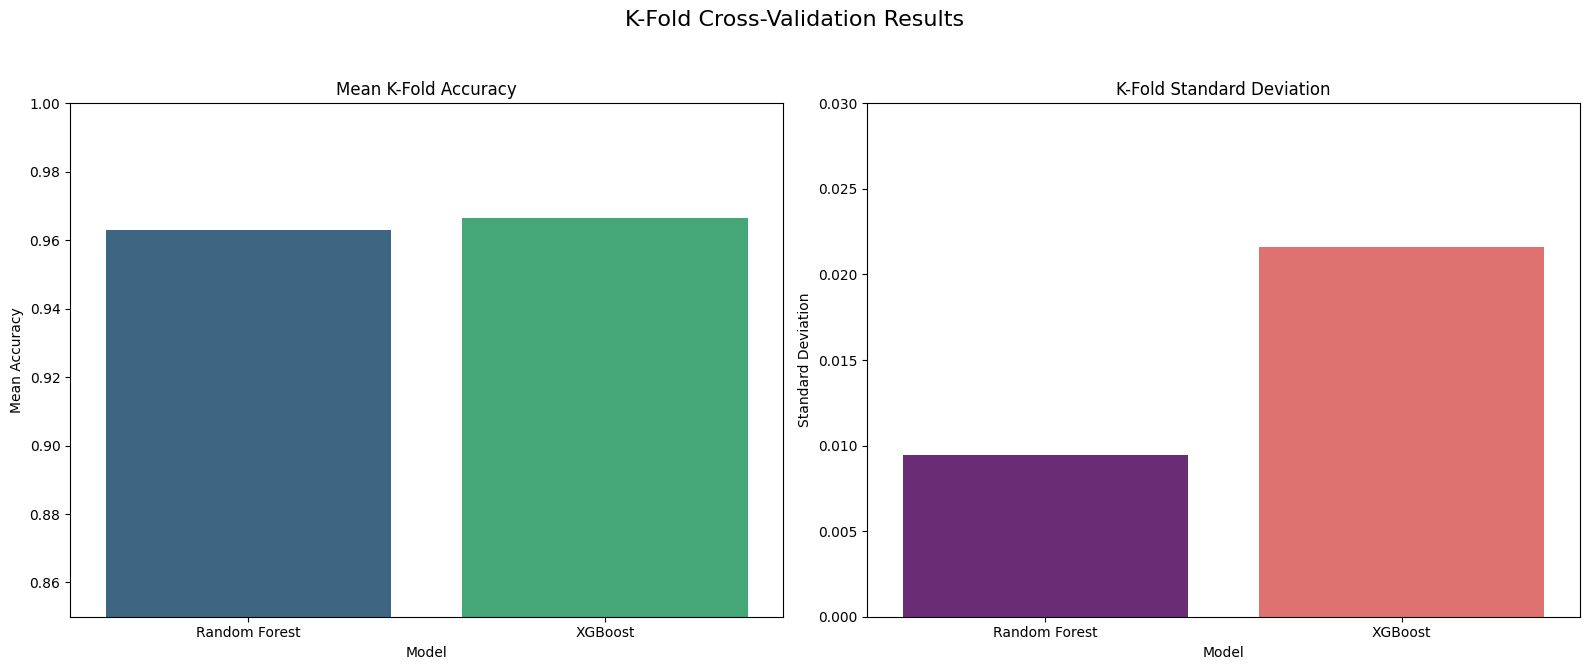

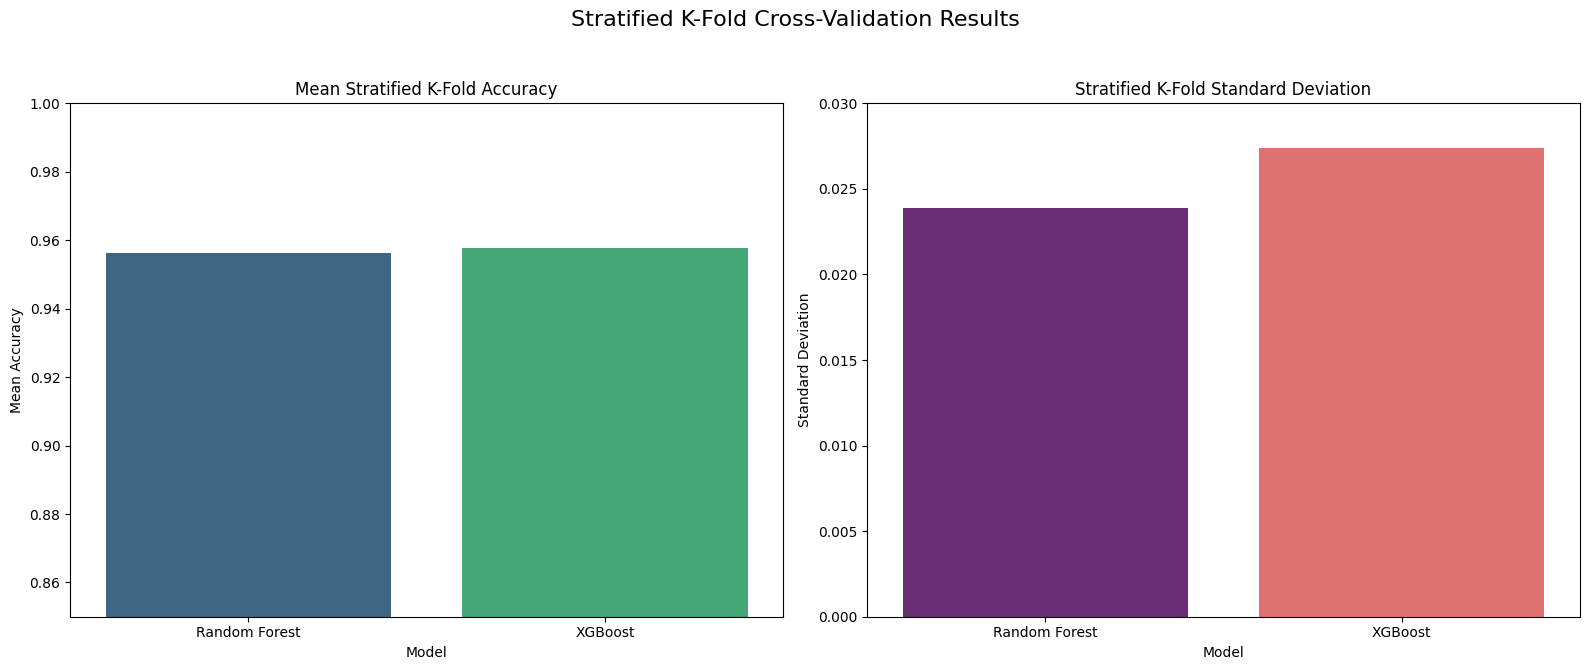

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for K-Fold plotting
kfold_data = {
    'Model': ['Random Forest', 'XGBoost'],
    'Mean Accuracy': [cv_scores_rf.mean(), cv_scores_xgb.mean()],
    'Standard Deviation': [cv_scores_rf.std(), cv_scores_xgb.std()]
}
kfold_df = pd.DataFrame(kfold_data)

# Data for Stratified K-Fold plotting
stratified_kfold_data = {
    'Model': ['Random Forest', 'XGBoost'],
    'Mean Accuracy': [cv_scores_rf_stratified.mean(), cv_scores_xgb_stratified.mean()],
    'Standard Deviation': [cv_scores_rf_stratified.std(), cv_scores_xgb_stratified.std()]
}
stratified_kfold_df = pd.DataFrame(stratified_kfold_data)

# --- K-Fold Cross-Validation Plots ---
plt.figure(figsize=(16, 7))
plt.suptitle('K-Fold Cross-Validation Results', fontsize=16)

# Plot Mean Accuracy for K-Fold
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Model', y='Mean Accuracy', data=kfold_df, palette='viridis')
plt.title('Mean K-Fold Accuracy')
plt.ylabel('Mean Accuracy')
plt.ylim(0.85, 1.0) # Set a reasonable y-limit for accuracy
plt.xticks(rotation=0)

# Plot Standard Deviation for K-Fold
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Model', y='Standard Deviation', data=kfold_df, palette='magma')
plt.title('K-Fold Standard Deviation')
plt.ylabel('Standard Deviation')
plt.ylim(0, 0.03) # Set a reasonable y-limit for standard deviation
plt.xticks(rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

# --- Stratified K-Fold Cross-Validation Plots ---
plt.figure(figsize=(16, 7))
plt.suptitle('Stratified K-Fold Cross-Validation Results', fontsize=16)

# Plot Mean Accuracy for Stratified K-Fold
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.barplot(x='Model', y='Mean Accuracy', data=stratified_kfold_df, palette='viridis')
plt.title('Mean Stratified K-Fold Accuracy')
plt.ylabel('Mean Accuracy')
plt.ylim(0.85, 1.0) # Set a reasonable y-limit for accuracy
plt.xticks(rotation=0)

# Plot Standard Deviation for Stratified K-Fold
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.barplot(x='Model', y='Standard Deviation', data=stratified_kfold_df, palette='magma')
plt.title('Stratified K-Fold Standard Deviation')
plt.ylabel('Standard Deviation')
plt.ylim(0, 0.03) # Set a reasonable y-limit for standard deviation
plt.xticks(rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

* **First Figure: K-Fold Cross-Validation Results**

   * **Mean K-Fold Accuracy:** This bar plot shows the average accuracy for Random Forest and XGBoost models obtained from standard K-Fold cross-validation. You'll notice that XGBoost has a slightly higher mean accuracy (0.9665) compared to Random Forest (0.9631).
   * **K-Fold Standard Deviation:** This plot displays the standard deviation of accuracy scores for both models during standard K-Fold. Here, Random Forest shows a slightly lower standard deviation (0.0094) than XGBoost (0.0216), indicating greater consistency in its performance across the different folds.

* **Second Figure: Stratified K-Fold Cross-Validation Results**

   * **Mean Stratified K-Fold Accuracy:** This bar plot shows the average accuracy for Random Forest and XGBoost models from Stratified K-Fold cross-validation. Similar to the standard K-Fold, XGBoost still maintains a marginal lead in mean accuracy (0.9579) over Random Forest (0.9561).

   * **Stratified K-Fold Standard Deviation:** This plot shows the standard deviation of accuracy scores for both models using Stratified K-Fold. In this case, Random Forest still exhibits slightly better consistency with a lower standard deviation (0.0239) compared to XGBoost (0.0274).
These separate visualizations make it clearer to compare the models' performance and stability under each specific cross-validation strategy.

### Model Performance Comparison

| Metric                          | Random Forest (Holdout) | XGBoost (Holdout) | Random Forest (K-Fold) | XGBoost (K-Fold) | Random Forest (Stratified K-Fold) | XGBoost (Stratified K-Fold) |
| :------------------------------ | :---------------------- | :---------------- | :--------------------- | :--------------- | :-------------------------------- | :-------------------------- |
| **Accuracy**                    | 0.9649                  | 0.9561            | -                      | -                | -                                 | -                           |
| **Mean Cross-Validation Acc.**  | -                       | -                 | 0.9631                 | 0.9665           | 0.9561                            | 0.9579                      |
| **Cross-Validation Std Dev.**   | -                       | -                 | 0.0094                 | 0.0216           | 0.0239                            | 0.0274                      |


**Key Observations:**

*   **XGBoost** generally shows a slightly higher **mean accuracy** across both K-Fold (0.9665) and Stratified K-Fold (0.9579) cross-validation compared to Random Forest.
*   **Random Forest** demonstrates slightly better **stability** with a lower standard deviation in its accuracy scores across the folds, particularly in the standard K-Fold (0.0094 vs 0.0216).
*   Both models perform exceptionally well, with high accuracy in classifying breast cancer diagnoses.
